# Traitement d'images : filtrage, seuillage, et comptage d'objets avec opencv

Une initiation à la biblithèque opencv 

# Veille technologique: Opencv python

-  Suivre les instructions et faire une recherche selon ce qui est demandé.

## Operations Simples

In [1]:
# use opencv to load and display the image  
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
from skimage.io import imread, imshow, imsave



In [2]:
# lire l'image (avec imread)
image = cv2.imread('ResourcesBrief/image_01.png')
if image is None:
    raise FileNotFoundError("Image not found!")
# afficher image
cv2.imshow("image 1", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
# afficher la taille de l'image
image.shape

(760, 541, 3)

760 x 541, 3 signifie que l'image est en couleur (RGB)

In [4]:
# l'image a trois couleur R,G,B. afficher les valeurs des trois couleurs pour le pixel x = 150, et y = 100
print (image[150,100])

[102 204 153]


In [5]:
# Crop une partie de l'image (sélectionner une petite partie à partir des coordonnées)
cropped = image[50:280, 100:400]  

In [6]:
cv2.imshow('original', image)
cv2.imshow('cropped', cropped)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
# redimensioner l'image à 200x200 pixels
new_dim = (200, 200)
resized = cv2.resize(image, new_dim)
# afficher resized
cv2.imshow('resized', resized)
cv2.waitKey(0)
cv2.destroyAllWindows()
# qu'est ce que vous remarquez !!


l'image est déformée (étirée ou écrasée) parce qu'on force des dimensions carrées (200×200) sans respecter le ratio d'aspect original de l'image.

In [8]:
# redimensionner sans affecter l'image
ratio = 200 / image.shape[1]  # ratio basé sur la largeur cible
new_dim = (200, int(image.shape[0] * ratio))
resized2 = cv2.resize(image, new_dim)
cv2.imshow('resized', resized)
cv2.imshow("resized sans affecter l'image", resized2)
cv2.waitKey(0)
cv2.destroyAllWindows()


using cv2

The cv2.rotate() function is a straightforward way to rotate an image by 90, 180, or 270 degrees. (not 45) <br>
We need to use the cv2.getRotationMatrix2D and cv2.warpAffine functions.

In [9]:
# faire tourner une image -45°
# Get the image dimensions
(h, w) = image.shape[:2]
(cX, cY) = (w // 2, h // 2)

# Create the rotation matrix
M = cv2.getRotationMatrix2D((cX, cY), 45, 1.0)

rotated = cv2.warpAffine(image, M, (w, h))
cv2.imshow("Rotation 45 degrés", rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

Vous pouvez utiliser la bibliothèque imutils pour faire les rotations et d'autres fonctions facilement. Pour l'instaler: pip install imutils

using imutils

In [10]:
import imutils
rotated = imutils.rotate(image, 45)
cv2.imshow("Rotation 45 degrés", rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Dessiner sur l'image

To draw a rectangle, you need top-left corner and bottom-right corner of rectangle.

we need a copy of the image so that original image stays the same

In [11]:
copie = image.copy()

In [12]:
# dessiner un rectangle
rectangle = cv2.rectangle(copie,(500,350),(200,200),(0,0,255),3)
cv2.imshow("Rectangle", rectangle)
cv2.waitKey(0)
cv2.destroyAllWindows()

To draw a circle, you need its center coordinates and radius.

In [13]:
# dessiner un circle
circle = cv2.circle(copie, (200,100),50,(0,255,0), 3)
cv2.imshow("Cercle", circle)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Filtrage d'image

* Blur
* Gaussian blur
* Median blur
* Sharpening
* Bilateral blur
* Bilateral filtering

In [14]:
# charger et afficher l'image "bois"
imagebois = cv2.imread("ResourcesBrief/bois.png")
cv2.imshow("Bois", imagebois)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [15]:
imagebois.shape

(1365, 2048, 3)

In [16]:
# Utiliser la méthode "cv2.filter2D" avec un kernel de taille 2
kernel = np.ones((2,2), np.float32)
filtered_img = cv2.filter2D(src=imagebois, ddepth=-1, kernel=kernel)

In [17]:
cv2.imshow('Original', imagebois)
cv2.imshow('Filtered', filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Un kernel rempli de 1 sans division va amplifier les valeurs des pixels au lieu de les moyenner, ce qui donne une image surexposée (toute blanche ou saturée).

In [18]:
kernel = np.ones((2,2), np.float32) /4 
filtered_img = cv2.filter2D(src=imagebois, ddepth=-1, kernel=kernel)

In [19]:
cv2.imshow('Original', imagebois)
cv2.imshow('Filtered', filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
# Appliquer blur avec un kernel de taille 5x5
blurred = cv2.blur(imagebois, (5,5))
cv2.imshow('Original', imagebois)
cv2.imshow('Blurred', blurred)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [21]:
# gaussian blur
gaussian = cv2.GaussianBlur(imagebois, (5,5), 0)
cv2.imshow('Original', imagebois)
cv2.imshow('Blurred', blurred)
cv2.imshow('Gaussian', gaussian)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [22]:
# median blur
median = cv2.medianBlur(imagebois,15)
cv2.imshow('Original', imagebois)
cv2.imshow('Blurred', blurred)
cv2.imshow('Gaussian', gaussian)
cv2.imshow('Median', median)
cv2.waitKey(0)
cv2.destroyAllWindows()


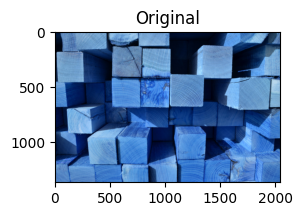

In [23]:
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(imagebois)

Pour garder un sharpening plus fort sans saturer, il faut que la somme du kernel reste à 1.

In [24]:
# sharpening

# Create the sharpening kernel
sharpenkernel = np.array([[0, -1, -1],
                          [-1,  7, -1],
                          [-1, -1, 0]])


# Sharpen the image
sharpened_image = cv2.filter2D(imagebois, -1, sharpenkernel)

cv2.imshow('Original', imagebois)
cv2.imshow('Sharpened', sharpened_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



A bilateral filter is a non-linear, edge-preserving, and noise-reducing smoothing filter for images. Unlike other filters, it does not blur the edges, making it highly effective for tasks where edge preservation is crucial.

In [25]:
# bilateral filtering
bilateral = cv2.bilateralFilter(imagebois, 15, 75, 75)

cv2.imshow('Original', imagebois)
cv2.imshow('Bilateral', bilateral)
cv2.waitKey(0)
cv2.destroyAllWindows()


# Seuillage d'image

En utilisant l'image "sudoku" appliquer:
* Binary Thresholding
* Otsu thresholding
* Adaptive thresholding

In [26]:
sudoku = cv2.imread("ResourcesBrief/sudoku.jpg")
sudoku.shape

(423, 419, 3)

In [27]:
cv2.imshow('Original', sudoku)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [28]:
# appliquer un seuillage binaire d'un seuil de 127
ret, thresh = cv2.threshold(sudoku, 127, 255, cv2.THRESH_BINARY)
cv2.imshow('Original', sudoku)
cv2.imshow('Thresholded', thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [29]:
# appliquer un seuillage binaire d'un seuil de 30
ret, thresh2 = cv2.threshold(sudoku, 30, 255, cv2.THRESH_BINARY)
cv2.imshow('Original', sudoku)
cv2.imshow('Thresholded1', thresh)
cv2.imshow('Thresholded2', thresh2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [30]:
# appliquer un seuillage binaire d'un seuil de 240
ret, thresh3 = cv2.threshold(sudoku, 240, 255, cv2.THRESH_BINARY)
cv2.imshow('Original', sudoku)
cv2.imshow('Thresholded1', thresh)
cv2.imshow('Thresholded2', thresh2)
cv2.imshow('Thresholded3', thresh3)
cv2.waitKey(0)
cv2.destroyAllWindows()

Qu'est ce que vous remarquez ?!

Seuil à 30 (thresh2) : presque tout l'image devient blanc (255), car très peu de pixels ont une valeur inférieure à 30. On ne garde que les zones très sombres en noir. <br>
Seuil à 240 (thresh3) : presque tout devient noir (0), car très peu de pixels dépassent 240.


C'est justement pour éviter de chercher ce seuil manuellement qu'on utilise le seuillage adaptatif ou Otsu :

In [31]:
sudoku.shape

(423, 419, 3)

In [32]:
# appliquer "Otsu" seuillage
# Convertir en niveaux de gris d'abord
gray = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

# Otsu trouve automatiquement le meilleur seuil
ret, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Seuil optimal trouvé par Otsu : {ret}")

Seuil optimal trouvé par Otsu : 96.0


Le seuillage adaptatif calcule un seuil différent pour chaque zone de l'image, ce qui est idéal pour des éclairages inégaux (comme une photo de sudoku avec des ombres) :

In [33]:
# appliquer "Adaptive threshold"
# Seuillage adaptatif - moyenne des voisins
adaptive_mean = cv2.adaptiveThreshold(gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, 11, 2)

# Seuillage adaptatif - gaussien (souvent meilleur)
adaptive_gauss = cv2.adaptiveThreshold(gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2)

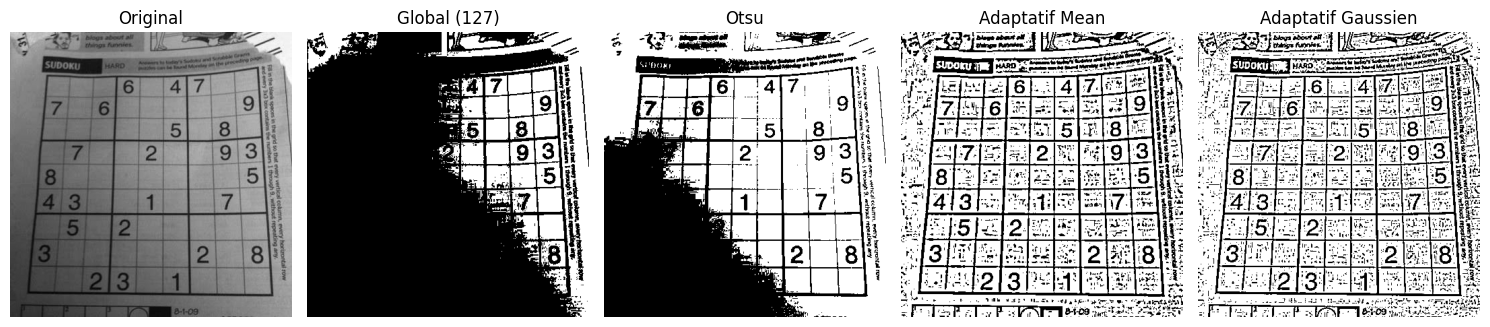

In [34]:
gray = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

# Seuillage global
_, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Otsu
_, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptatif mean
adaptive_mean = cv2.adaptiveThreshold(gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Adaptatif gaussien
adaptive_gauss = cv2.adaptiveThreshold(gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Affichage
titles = ['Original', 'Global (127)', 'Otsu', 'Adaptatif Mean', 'Adaptatif Gaussien']
images = [gray, thresh_global, thresh_otsu, adaptive_mean, adaptive_gauss]

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Les méthodes adaptatives gèrent bien mieux les variations de luminosité

# Détection des bords

* Sobel
* Canny

Le principe : Sobel utilise deux kernels 3×3 qui calculent le gradient (la variation d'intensité) dans chaque direction. <br> Sobel X capte les transitions gauche/droite (contours verticaux), <br> Sobel Y les transitions haut/bas (contours horizontaux). magnitude combine les deux pour avoir tous les contours.

In [35]:
# utiliser la methode sobel pour détecter les bords
# Vous pouvez utiliser d'autres images de votre choix
# Sobel horizontal (détecte les contours verticaux)
sobel_x = cv2.Sobel(sudoku, cv2.CV_64F, 1, 0, ksize=3)

# Sobel vertical (détecte les contours horizontaux)
sobel_y = cv2.Sobel(sudoku, cv2.CV_64F, 0, 1, ksize=3)

sobel_combined = cv2.magnitude(sobel_x, sobel_y)


# Convertir en uint8 pour l'affichage
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)
sobel_combined_abs = cv2.convertScaleAbs(sobel_combined)



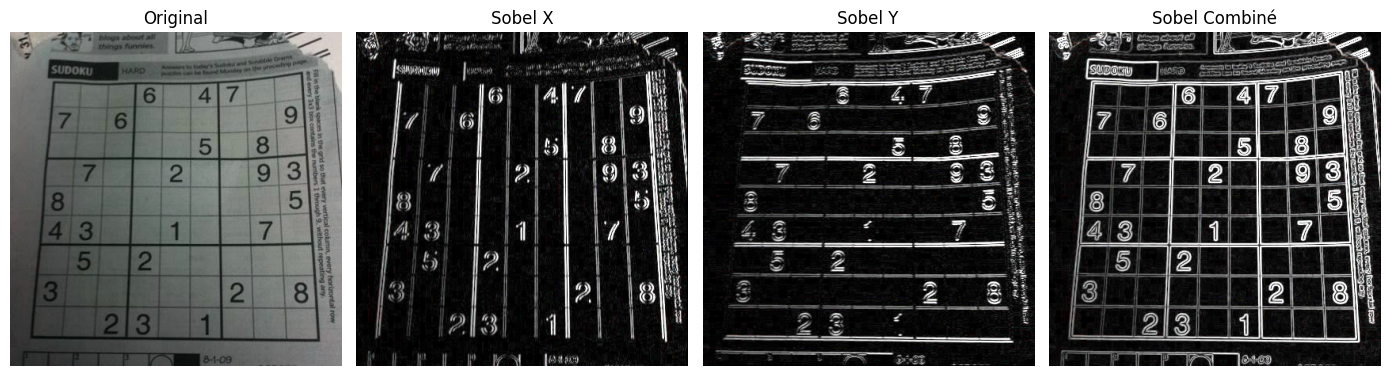

In [36]:
# Affichage
titles = ['Original', 'Sobel X', 'Sobel Y', 'Sobel Combiné']
images = [sudoku, sobel_x_abs, sobel_y_abs, sobel_combined_abs]

plt.figure(figsize=(14, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

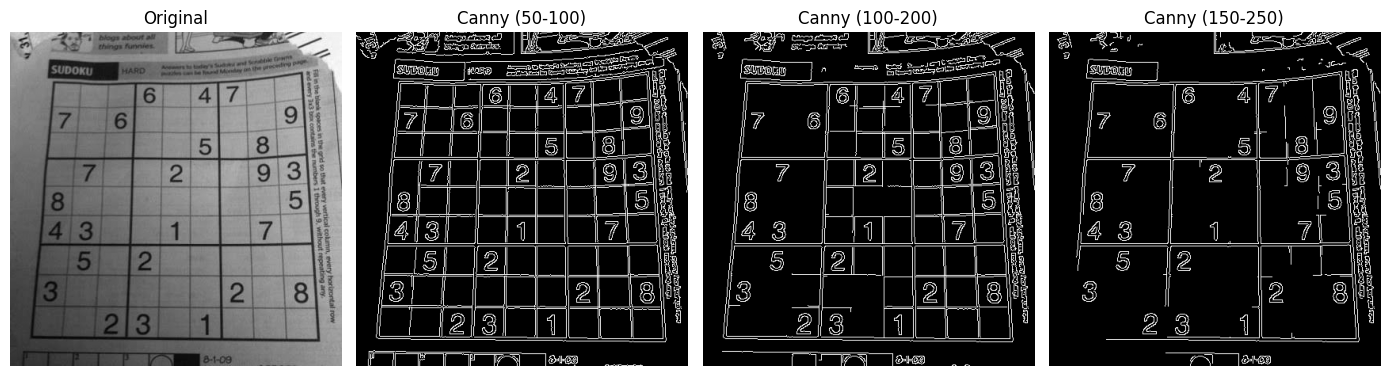

In [37]:
# Canny

# Canny avec différents seuils
canny1 = cv2.Canny(gray, 50, 100)
canny2 = cv2.Canny(gray, 100, 200)
canny3 = cv2.Canny(gray, 150, 250)

# Affichage
titles = ['Original', 'Canny (50-100)', 'Canny (100-200)', 'Canny (150-250)']
images = [gray, canny1, canny2, canny3]

plt.figure(figsize=(14, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Canny est plus avancé que Sobel — il fait en interne :

Flou gaussien pour réduire le bruit

Gradient (comme Sobel) pour trouver les contours, Recherche des zones où l'intensité lumineuse change brusquement.

Suppression des non-maxima pour affiner les contours à 1 pixel d'épaisseur

Double seuillage (les deux paramètres) : le seuil bas garde les contours faibles connectés à des contours forts, le seuil haut valide les contours forts, On utilise deux seuils (bas et haut) pour décider si un pixel est un "vrai" contour ou du bruit.

Plus les seuils sont bas → plus de contours détectés (mais plus de bruit). Plus ils sont hauts → contours plus nets mais on en perd.

# Détection des contours

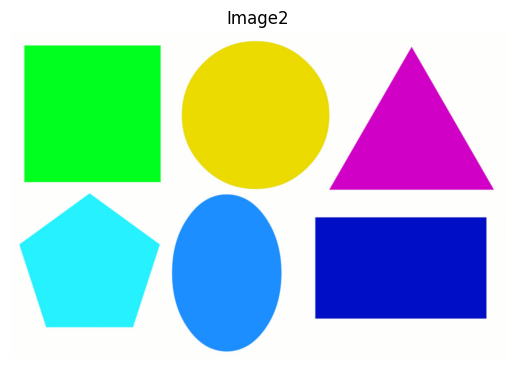

In [38]:
# charger l'image 02
# faites une recherche sur internet pour détecter les contours des objets dans image_02

image2 = cv2.imread('ResourcesBrief/image_02.png')

plt.imshow(image2)
plt.title('Image2')
plt.axis('off')
cv2.imshow('Image2', image2)
cv2.waitKey(0)
cv2.destroyAllWindows()

(np.float64(-0.5), np.float64(1310.5), np.float64(864.5), np.float64(-0.5))

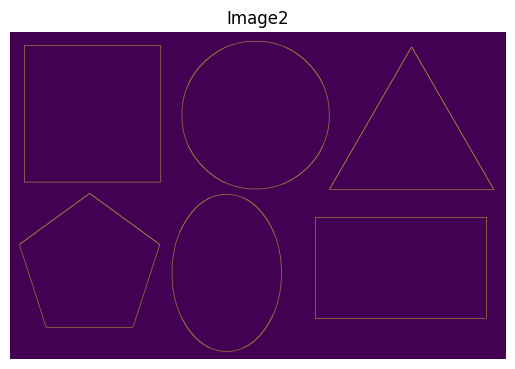

In [39]:
edges = cv2.Canny(image2, 50,150)
plt.imshow(edges)
plt.title('Image2')
plt.axis('off')

In [40]:
# 2. Convertir en niveaux de gris (Canny travaille sur une seule couche)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# 3. Appliquer un léger flou pour éviter les faux contours dus au bruit
blurred2 = cv2.GaussianBlur(gray2, (5, 5), 0)

edges2 = cv2.Canny(blurred2, 50, 100)

cv2.imshow('Originak', image2)
cv2.imshow('Contours Canny', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

#  Compter des objets

Pour compter, l'ordinateur suit ce pipeline :

Binarisation : Transformer l'image en noir et blanc pur (les objets en blanc, le fond en noir).

Recherche de contours : Identifier les groupes de pixels blancs connectés.

Filtrage : Ignorer les petits bruits qui ne sont pas de "vrais" objets.

In [41]:
# Compter les objets
# Trouver les contours

# Utiliser un seuillage inverse car le fond est blanc
_, thresh = cv2.threshold(gray2, 240, 255, cv2.THRESH_BINARY_INV)

# cv2.RETR_EXTERNAL permet de ne pas compter les "trous" à l'intérieur des formes
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
nombre_objets = len(contours)
print(f"Nombre d'objets détectés : {nombre_objets}")


Nombre d'objets détectés : 6


In [42]:
cv2.drawContours(image2, contours, -1, (0, 0, 0), 2)
cv2.imshow('Objets identifies', image2)
cv2.waitKey(0)
cv2.destroyAllWindows()

Pour identifier les formes, on utilise une technique appelée l'approximation de polygone. L'idée est de simplifier le contour détecté pour ne garder que les sommets (les coins). <br>
En comptant ces sommets, on peut déduire la nature de la forme.

In [43]:
for cnt in contours:
    # 1. Calculer le périmètre pour la précision de l'approximation
    peri = cv2.arcLength(cnt, True)
    # 2. Approximer la forme (réduire le nombre de points)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    
    # Récupérer les coordonnées pour écrire le texte
    x, y, w, h = cv2.boundingRect(approx)
    nom_forme = "Inconnu"

    # 3. Identifier selon le nombre de sommets
    if len(approx) == 3:
        nom_forme = "Triangle"
    elif len(approx) == 4:
        aspect_ratio = float(w) / h
        nom_forme = "Carre" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"
    elif len(approx) == 5:
        nom_forme = "Pentagone"
    else:
        aspect_ratio = float(w) / h
        nom_forme = "Cercle" if 0.95 <= aspect_ratio <= 1.05 else "Ovale"

    # Afficher le résultat sur l'image
    cv2.putText(image2, nom_forme, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
    cv2.drawContours(image2, contours, -1, (0, 0, 0), 2)

cv2.imshow('Identification', image2)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Challenge
Compter le nombre d'objets dans l'image 03 avec le code précédent.
- Qu'est ce que vous remarquez?
- Utiliser l'algorithme Watershed pour detecter et séparer les objets connectés.

In [44]:
image3 = cv2.imread('ResourcesBrief/image_03.jpg')
cv2.imshow('Original', image3)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [45]:
image3.shape

(631, 957, 3)

In [46]:
# Convertir en niveaux de gris (Canny travaille sur une seule couche)
gray3 = cv2.cvtColor(image3, cv2.COLOR_BGR2GRAY)

# 3. Appliquer un léger flou pour éviter les faux contours dus au bruit
blurred3 = cv2.GaussianBlur(gray3, (5, 5), 0)

edges3 = cv2.Canny(blurred3, 50, 100)

cv2.imshow('Original', image3)
cv2.imshow('Contours Canny', edges3)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [47]:
# Seuillage
_, thresh = cv2.threshold(gray3, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours_before, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Objets AVANT watershed : {len(contours_before)}")

Objets AVANT watershed : 1


In [48]:
# Dessiner les contours avant
img_before = image3.copy()
cv2.drawContours(img_before, contours_before, -1, (0, 255, 0), 2)
cv2.imshow('Original', image3)
cv2.imshow('Contours Canny', img_before)
cv2.waitKey(0)
cv2.destroyAllWindows()

Le principe de Watershed (ligne de partage des eaux) :

Seuillage → séparer objets/fond grossièrement<br>
Opening → enlever le bruit<br>
Distance transform → trouver le "centre" de chaque objet (les pixels les plus éloignés des bords)<br>
Marqueurs → identifier chaque objet et le fond avec certitude<br>
Zone inconnue → là où les objets se touchent, c'est la zone à départager<br>
Watershed → "remplit" depuis les marqueurs comme de l'eau qui monte, les frontières (-1) se forment là où deux "bassins" se rencontrent<br>

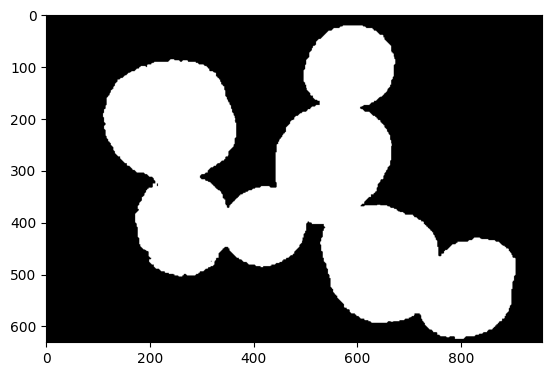

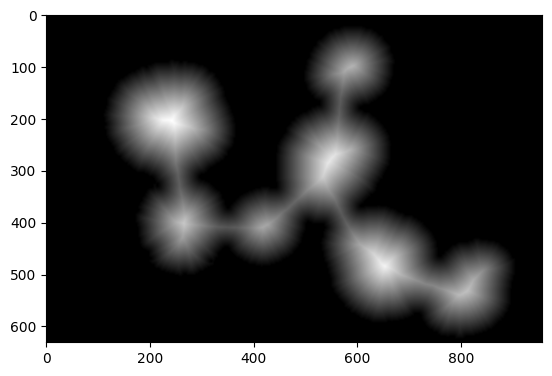

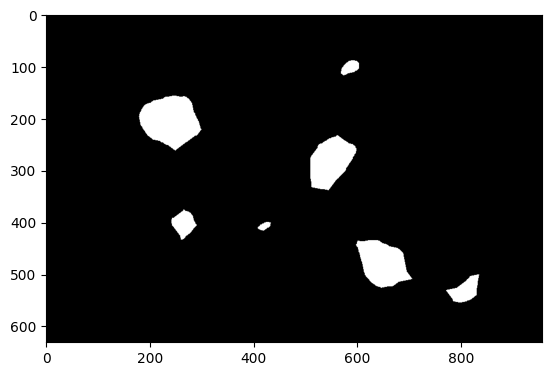

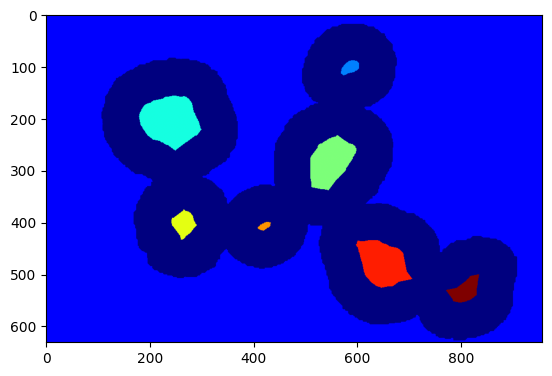

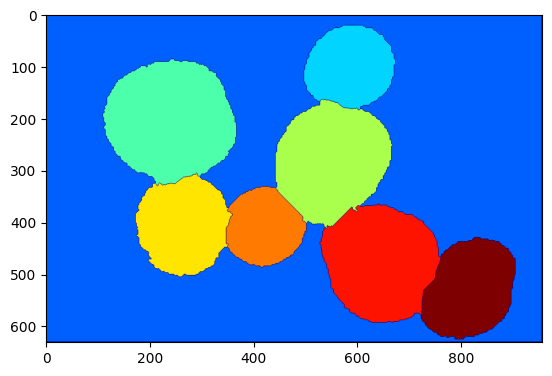

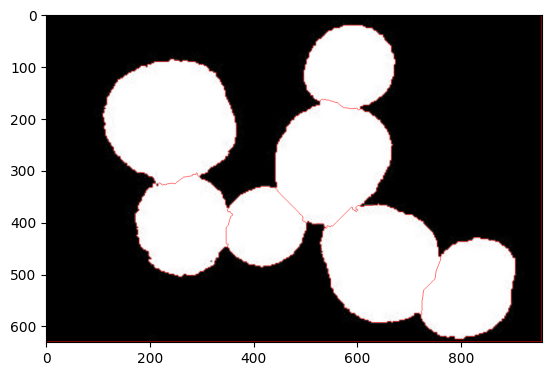

Objets détectés : 7


In [55]:
image = cv2.imread("ResourcesBrief/image_03.jpg")
gray = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
 
seuil, img_thresh = cv2.threshold(src=gray, thresh=0, maxval=255, type=(cv2.THRESH_BINARY + cv2.THRESH_OTSU))
 
# Élimination du bruit blanc
kernel = np.ones(shape=(3,3), dtype=np.uint8)
opening = cv2.morphologyEx(img_thresh, kernel=kernel, op=cv2.MORPH_OPEN, iterations=2)
 
# Identification du background
sure_bg = cv2.dilate(opening, kernel=kernel, iterations=3)
 
# Identification du premier plan
dist_transform = cv2.distanceTransform(opening, distanceType=cv2.DIST_L2, maskSize=5)
seuil, premier_plan_sur = cv2.threshold(dist_transform, thresh=(0.6*dist_transform.max()), maxval=255, type=cv2.THRESH_BINARY)
 
# Identification des régions inconues
plt.imshow(opening, cmap='gray')
plt.show()
plt.imshow(dist_transform, cmap='gray')
plt.show()
plt.imshow(premier_plan_sur, cmap='gray')
plt.show()
 
# repérages des régions incertaines
premier_plan_sur = np.uint8(premier_plan_sur)
inconues = cv2.subtract(sure_bg, premier_plan_sur)
 
# Création de marqueurs à partir de premier plan sur
ret, markers = cv2.connectedComponents(premier_plan_sur)
 
# Signalement des marqueurs 
markers = markers+1
 
# Signalement des marqueurs inconnus
markers[inconues==255] = 0
plt.imshow(markers, cmap='jet')
plt.show()
markers = cv2.watershed(image=image, markers=markers)
image[markers == -1] = [255,0,0]
 
plt.imshow(markers, cmap='jet')
plt.show()
plt.imshow(image, cmap='jet')
plt.show()
nb_objets = len(np.unique(markers)) - 2  # -2 pour fond et contours
print(f"Objets détectés : {nb_objets}")

Objets APRÈS watershed : 4


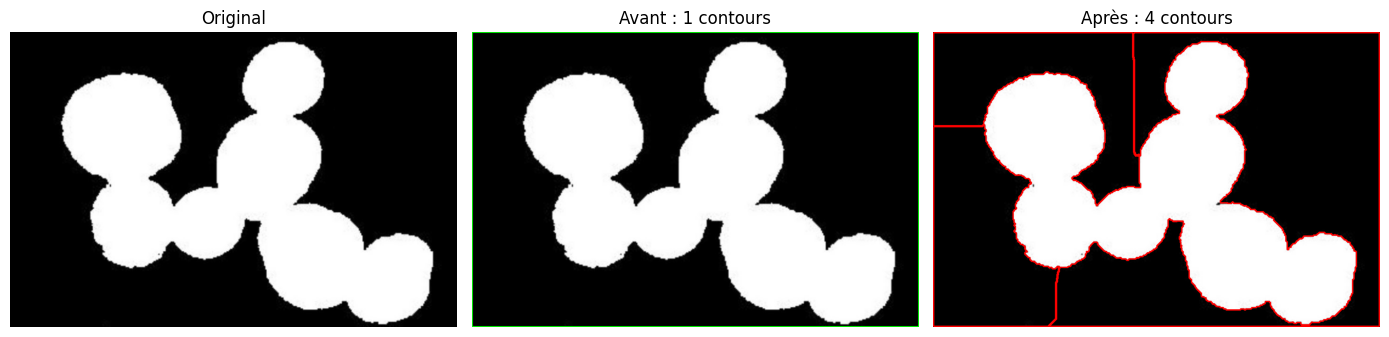

In [ ]:
# --- WATERSHED ---
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(image3, markers)

# --- COMPTAGE APRÈS WATERSHED avec findContours ---
# Créer un masque pour chaque objet séparé
img_after = image3.copy()
contours_after = []
for label in np.unique(markers):
    if label <= 1:  # ignorer fond et contours
        continue
    mask = np.uint8(markers == label) * 255
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_after.extend(cnts)

cv2.drawContours(img_after, contours_after, -1, (0, 0, 255), 2)
print(f"Objets APRÈS watershed : {len(contours_after)}")

# Affichage
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image3, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
plt.title(f'Avant : {len(contours_before)} contours')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
plt.title(f'Après : {len(contours_after)} contours')
plt.axis('off')

plt.tight_layout()
plt.show()

Bravo !

# Mona

In [ ]:
mona = cv2.imread('ResourcesBrief/mona.png')
cv2.imshow('Original', mona)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
mona.shape

(561, 375, 3)

In [ ]:
# Convertir en niveaux de gris d'abord
graymona = cv2.cvtColor(mona, cv2.COLOR_BGR2GRAY)
cv2.imshow('Original', mona)
cv2.imshow('Gray', graymona)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
retmona, thresh_otsu_mona = cv2.threshold(graymona, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Seuil optimal trouvé par Otsu : {retmona}")

# Seuillage adaptatif - moyenne des voisins
adaptive_mean_mona = cv2.adaptiveThreshold(graymona, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, 11, 2)

# Seuillage adaptatif - gaussien (souvent meilleur)
adaptive_gauss_mona = cv2.adaptiveThreshold(graymona, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2)

Seuil optimal trouvé par Otsu : 115.0


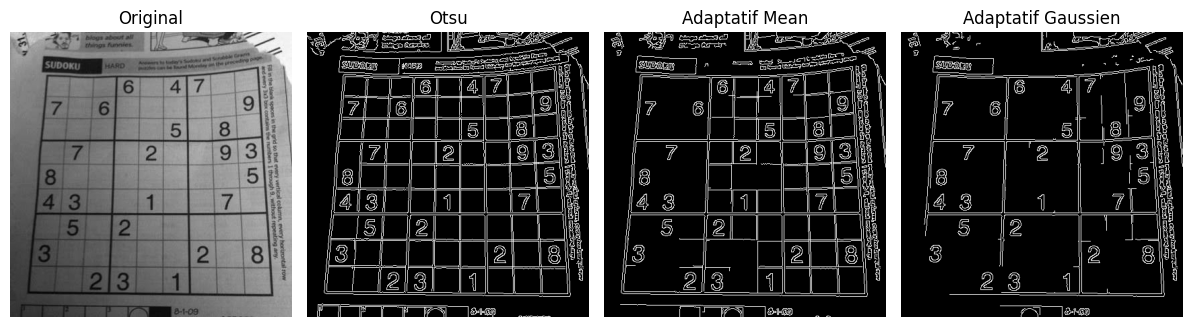

In [ ]:
# Affichage
titlesmona = ['Original', 'Otsu', 'Adaptatif Mean', 'Adaptatif Gaussien']
imagesmona = [graymona, thresh_otsu_mona, adaptive_mean_mona, adaptive_gauss_mona]

plt.figure(figsize=(15, 6))
for i in range(len(imagesmona)):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titlesmona[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Create the sharpening kernel
sharpenkernel = np.array([[0, -1, -1],
                          [-1,  7, -1],
                          [-1, -1, 0]])


# Sharpen the image
sharpened_image = cv2.filter2D(mona, -1, sharpenkernel)

cv2.imshow('Original', mona)
cv2.imshow('Otsu', sharpened_image)
cv2.imshow('Sharpened', sharpened_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


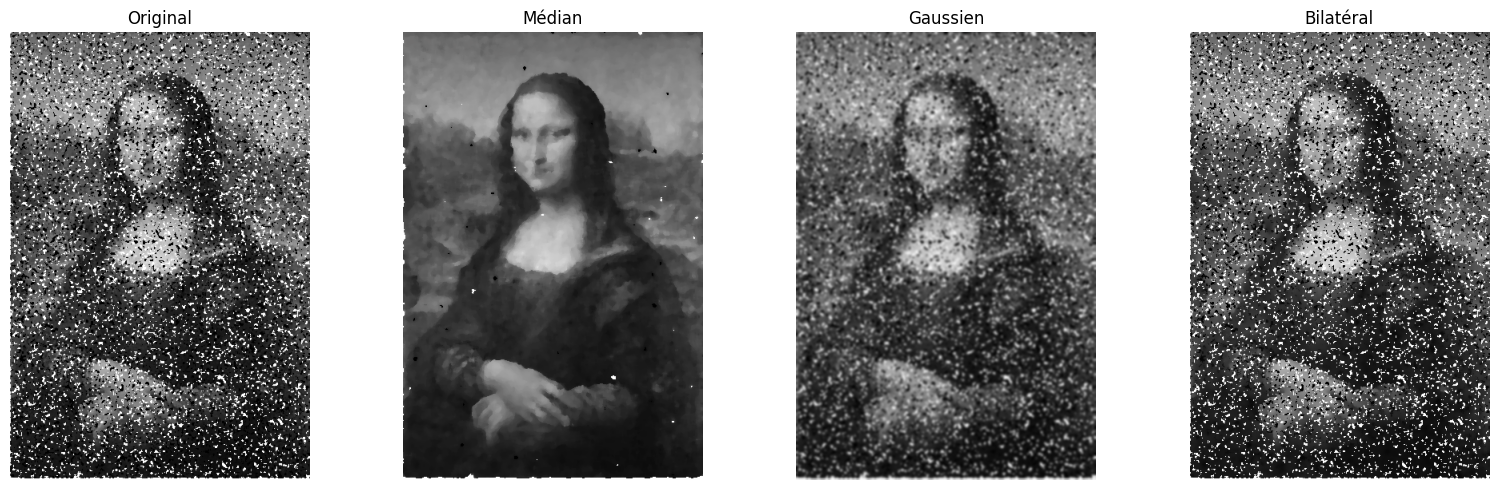

In [ ]:
# Filtre médian — idéal pour sel et poivre
medianmona = cv2.medianBlur(mona, 7)

# Comparer avec d'autres filtres
gaussianmona = cv2.GaussianBlur(mona, (7, 7), 0)
bilateralmona = cv2.bilateralFilter(mona, 9, 75, 75)

# Affichage
titles = ['Original', 'Médian', 'Gaussien', 'Bilatéral']
images = [mona, medianmona, gaussianmona, bilateralmona]

plt.figure(figsize=(16, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Affiner après débruitage
sharpen9 = np.array([[-1, -1, -1],
                    [-1,  9, -1],
                    [-1, -1, -1]])

sharpen7 = np.array([[0, -1, -1],
                    [-1,  7, -1],
                    [-1, -1, 0]])

sharpen5 = np.array([[0, -1, 0],
                    [-1,  5, -1],
                    [0, -1, 0]])

result9 = cv2.filter2D(medianmona, -1, sharpen9)
result7 = cv2.filter2D(medianmona, -1, sharpen7)
result5 = cv2.filter2D(medianmona, -1, sharpen5)

cv2.imshow('Original', mona)
cv2.imshow('median', medianmona)
cv2.imshow('Sharpened9', result9)
cv2.imshow('Sharpened7', result7)
cv2.imshow('Sharpened5', result5)
cv2.waitKey(0)
cv2.destroyAllWindows()



In [ ]:
# Non-local means — préserve mieux les détails
denoised = cv2.fastNlMeansDenoising(mona, None, h=80)

cv2.imshow('NlMeans', denoised)
cv2.imshow('Median', cv2.medianBlur(mona, 7))
cv2.waitKey(0)
cv2.destroyAllWindows()